In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, array, posexplode, count, avg, sum as _sum, expr

# SparkSession initialisieren
spark = SparkSession.builder \
    .appName("SEO_Analysis_with_Spark") \
    .getOrCreate()


In [8]:
# Pfade anpassen, falls nötig
path_serp        = "serp_reduced.csv"
path_duck        = "search_results_duckduckgo.csv"
path_duck_usa    = "search_results_duckduckgo_USA.csv"

serp_df     = spark.read.option("header", True).csv(path_serp)
duck_df     = spark.read.option("header", True).csv(path_duck)
duck_usa_df = spark.read.option("header", True).csv(path_duck_usa)


In [9]:
# Spalten umbenennen und Source‐Spalte hinzufügen
serp_df = (
    serp_df
    .withColumnRenamed("searchTerms", "search_term")
    .withColumnRenamed("displayLink", "domain")
    .withColumn("rank", col("rank").cast("int"))
    .withColumn("source", lit("SERP"))
)


In [10]:
# Link-Spalten als Array und dann posexplode für rank
link_cols = [f"link{i}" for i in range(1, 11)]

duck_long = (
    duck_df
    .withColumn("domains", array(*link_cols))
    .select("search_term", "domains")
    .withColumn("source", lit("DuckDuckGo"))
    .selectExpr("search_term", "posexplode(domains) as (pos, domain)", "source")
    .withColumn("rank", col("pos") + 1)
    .drop("pos")
)

duck_usa_long = (
    duck_usa_df
    .withColumn("domains", array(*link_cols))
    .select("search_term", "domains")
    .withColumn("source", lit("DuckDuckGo_USA"))
    .selectExpr("search_term", "posexplode(domains) as (pos, domain)", "source")
    .withColumn("rank", col("pos") + 1)
    .drop("pos")
)


In [11]:
# Platz 1 = 10 Punkte → score = 11 - rank
serp_df        = serp_df.withColumn("score", expr("11 - rank"))
duck_long      = duck_long.withColumn("score", expr("11 - rank"))
duck_usa_long  = duck_usa_long.withColumn("score", expr("11 - rank"))


In [12]:
def get_stats(df):
    return (
        df.groupBy("domain")
          .agg(
              count("*").alias("appearances"),
              avg("rank").alias("avg_rank"),
              _sum("score").alias("total_score")
          )
          .orderBy(col("total_score").desc())
    )

stats_serp     = get_stats(serp_df).limit(15)
stats_duck     = get_stats(duck_long).limit(15)
stats_duck_usa = get_stats(duck_usa_long).limit(15)


In [13]:
# Für die Visualisierung kleine Datasets in Pandas umwandeln
stats_serp_pd     = stats_serp.toPandas()
stats_duck_pd     = stats_duck.toPandas()
stats_duck_usa_pd = stats_duck_usa.toPandas()


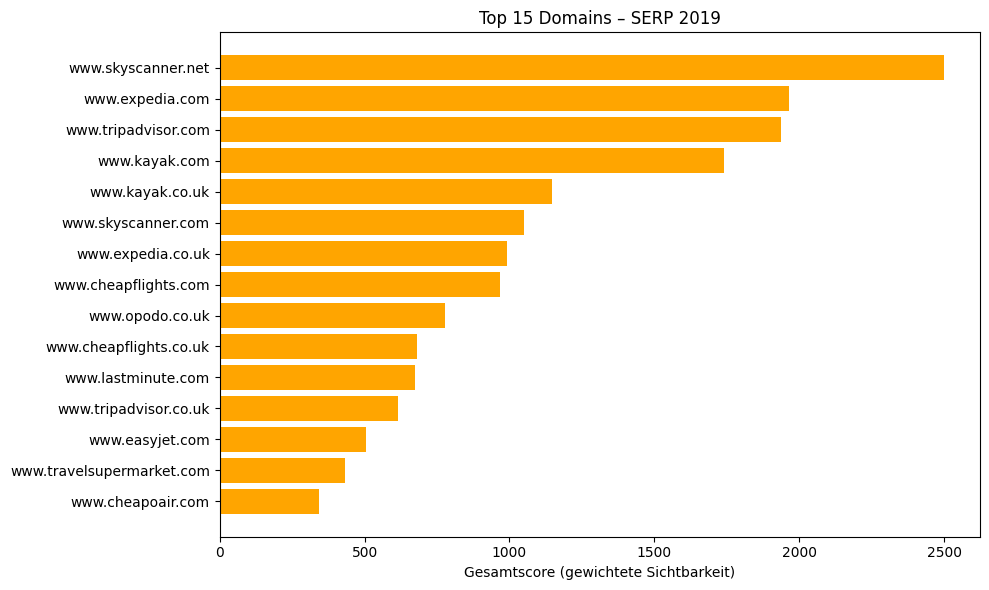

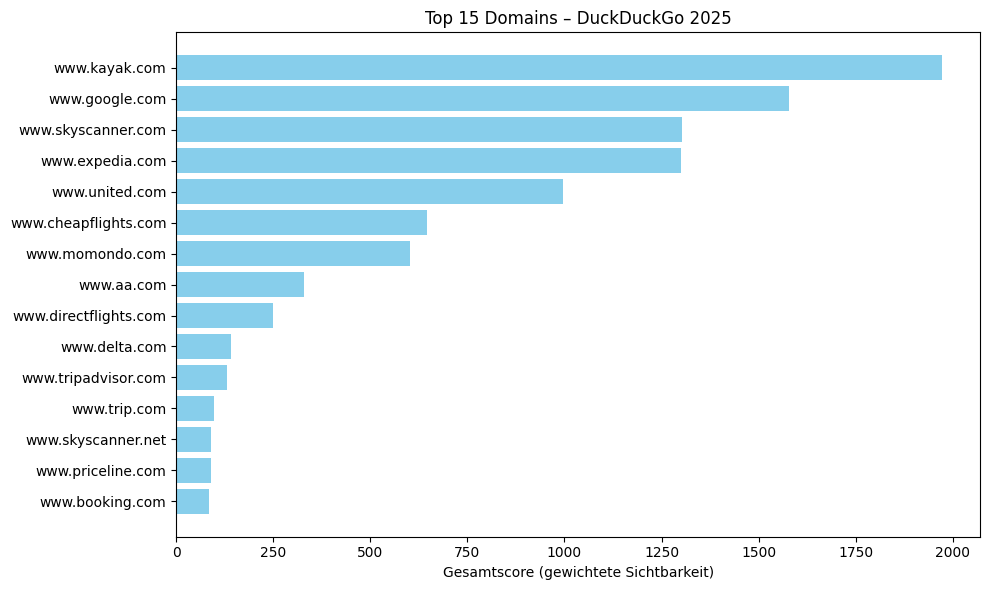

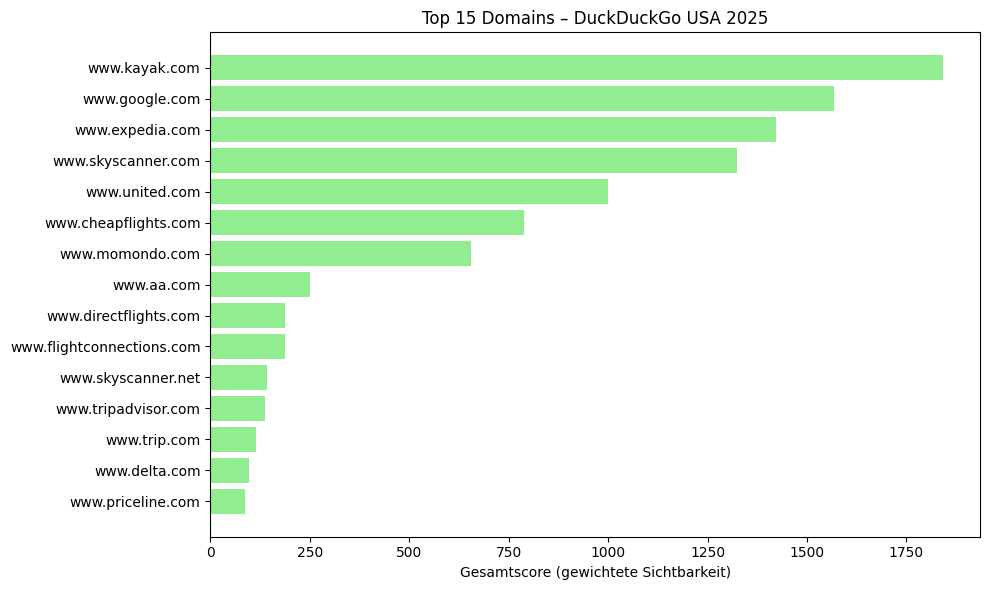

In [14]:
import matplotlib.pyplot as plt

# Hilfsfunktion
def plot_top15(df_pd, title, color):
    plt.figure(figsize=(10, 6))
    plt.barh(df_pd['domain'], df_pd['total_score'], color=color)
    plt.xlabel("Gesamtscore (gewichtete Sichtbarkeit)")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_top15(stats_serp_pd,     "Top 15 Domains – SERP 2019",          "orange")
plot_top15(stats_duck_pd,     "Top 15 Domains – DuckDuckGo 2025",    "skyblue")
plot_top15(stats_duck_usa_pd, "Top 15 Domains – DuckDuckGo USA 2025","lightgreen")


In [ ]:
spark.stop()